# Symbol CNN training

This notebook trains the grayscale UNO symbol CNN, shows the train/validation split, plots the training curves, and reports validation scores plus the confusion matrix.

It uses the existing `symbols_dataset` and `labels.json`. No augmentation, oversampling, undersampling, or class-weighted loss is used here.

In [1]:
from collections import Counter
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset

notebook_dir = Path.cwd()
if (notebook_dir / "train_cnn.py").exists():
    sys.path.insert(0, str(notebook_dir))
    project_dir = notebook_dir.parent
elif (notebook_dir / "project" / "symbol_classification" / "train_cnn.py").exists():
    sys.path.insert(0, str(notebook_dir / "project" / "symbol_classification"))
    project_dir = notebook_dir / "project"
else:
    raise RuntimeError("Run this notebook from the repo root or project/symbol_classification")

from train_cnn import (
    DEFAULT_DATASET_DIR,
    DEFAULT_OUTPUT_PATH,
    SymbolCNN,
    SymbolDataset,
    choose_device,
    count_trainable_parameters,
    compute_confusion_matrix,
    load_class_mapping,
    print_confusion_matrix,
    run_epoch,
    seed_everything,
    stratified_split,
)

torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"

('2.8.0+cu128', True, 'NVIDIA GeForce RTX 3090 Ti')

## Configuration

In [2]:
args = SimpleNamespace(
    dataset_dir=DEFAULT_DATASET_DIR,
    output=DEFAULT_OUTPUT_PATH,
    epochs=25,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    val_fraction=0.2,
    seed=42,
    num_workers=0,
    device="cuda",
    cpu=False,
)

seed_everything(args.seed)
device = choose_device(args)
device

device(type='cuda')

## Dataset and split

In [3]:
class_to_idx = load_class_mapping(args.dataset_dir)
idx_to_class = {idx: label for label, idx in class_to_idx.items()}
dataset = SymbolDataset(args.dataset_dir, class_to_idx)
train_indices, val_indices = stratified_split(dataset, args.val_fraction, args.seed)

def count_labels(indices):
    return Counter(idx_to_class[dataset.samples[idx][1]] for idx in indices)

train_counts = count_labels(train_indices)
val_counts = count_labels(val_indices)
rows = []
for label in class_to_idx:
    rows.append((label, train_counts[label], val_counts[label], train_counts[label] + val_counts[label]))

print(f"Total images: {len(dataset)}")
print(f"Train images: {len(train_indices)}")
print(f"Validation images: {len(val_indices)}")
print("\nlabel      train   val   total")
for label, train_count, val_count, total_count in rows:
    print(f"{label:>8} {train_count:7d} {val_count:5d} {total_count:7d}")

Total images: 1090
Train images: 871
Validation images: 219

label      train   val   total
       0      43    11      54
       1      55    14      69
       2      77    19      96
       3      68    17      85
       4      86    21     107
       5      67    17      84
       6      54    14      68
       7      98    25     123
       8      83    21     104
       9      38    10      48
  draw_2      50    12      62
  draw_4      18     5      23
 reverse      48    12      60
    skip      50    12      62
    wild      36     9      45


In [4]:
train_loader = DataLoader(
    Subset(dataset, train_indices),
    batch_size=args.batch_size,
    shuffle=True,
    num_workers=args.num_workers,
    pin_memory=device.type == "cuda",
)
val_loader = DataLoader(
    Subset(dataset, val_indices),
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    pin_memory=device.type == "cuda",
)

## Train

In [5]:
model = SymbolCNN(num_classes=len(class_to_idx)).to(device)
parameter_count = count_trainable_parameters(model)
print(f"Trainable parameters: {parameter_count:,}")
assert parameter_count <= 12_000_000

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)

history = []
best_val_acc = 0.0
args.output.parent.mkdir(parents=True, exist_ok=True)

print(f"Training on {device} with {len(train_indices)} train and {len(val_indices)} validation images")
for epoch in range(1, args.epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, None, device)
    scheduler.step()

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )
    print(
        f"epoch {epoch:02d}/{args.epochs} "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}"
    )

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "model_state": model.state_dict(),
                "class_to_idx": class_to_idx,
                "idx_to_class": idx_to_class,
                "image_size": 64,
                "val_acc": val_acc,
            },
            args.output,
        )

print(f"Best validation accuracy: {best_val_acc:.3f}")
print(f"Saved checkpoint to {args.output}")

Trainable parameters: 141,423
Training on cuda with 871 train and 219 validation images
epoch 01/25 train_loss=2.6750 train_acc=0.117 val_loss=2.7003 val_acc=0.064
epoch 02/25 train_loss=2.5379 train_acc=0.191 val_loss=2.6680 val_acc=0.096
epoch 03/25 train_loss=2.4405 train_acc=0.241 val_loss=2.6366 val_acc=0.096
epoch 04/25 train_loss=2.3831 train_acc=0.261 val_loss=2.6086 val_acc=0.096
epoch 05/25 train_loss=2.3003 train_acc=0.320 val_loss=2.5413 val_acc=0.096
epoch 06/25 train_loss=2.2128 train_acc=0.357 val_loss=2.4233 val_acc=0.151
epoch 07/25 train_loss=2.1473 train_acc=0.386 val_loss=2.2611 val_acc=0.237
epoch 08/25 train_loss=2.0444 train_acc=0.405 val_loss=2.0874 val_acc=0.324
epoch 09/25 train_loss=1.9661 train_acc=0.445 val_loss=1.9731 val_acc=0.347
epoch 10/25 train_loss=1.8820 train_acc=0.474 val_loss=1.8533 val_acc=0.416
epoch 11/25 train_loss=1.8158 train_acc=0.498 val_loss=1.7644 val_acc=0.530
epoch 12/25 train_loss=1.7509 train_acc=0.526 val_loss=1.6844 val_acc=0.539


## Training curves

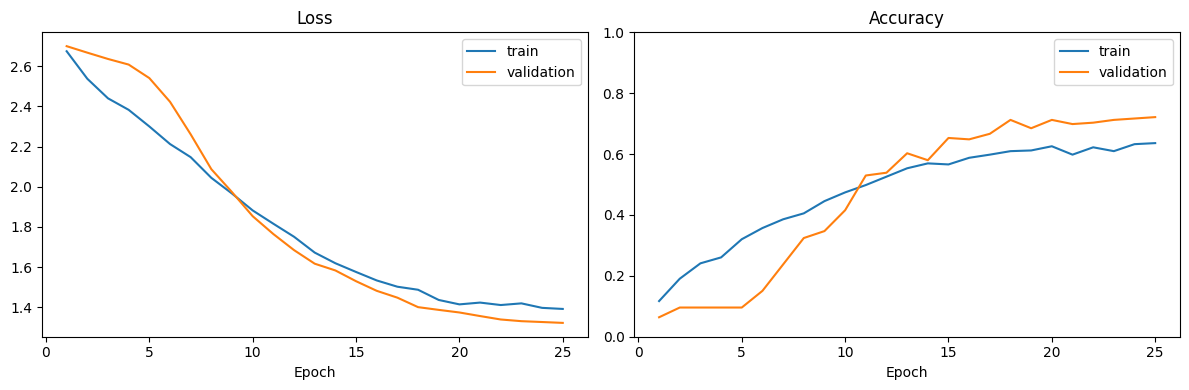

In [6]:
epochs = [row["epoch"] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [row["train_loss"] for row in history], label="train")
axes[0].plot(epochs, [row["val_loss"] for row in history], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, [row["train_acc"] for row in history], label="train")
axes[1].plot(epochs, [row["val_acc"] for row in history], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()

## Validation scores and confusion matrix

In [7]:
checkpoint = torch.load(args.output, map_location=device)
model.load_state_dict(checkpoint["model_state"])
matrix = compute_confusion_matrix(model, val_loader, len(class_to_idx), device)
print_confusion_matrix(matrix, idx_to_class)

true_positive = matrix.diag().float()
support = matrix.sum(dim=1).float()
predicted = matrix.sum(dim=0).float()
precision = true_positive / predicted.clamp_min(1)
recall = true_positive / support.clamp_min(1)
f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)

overall_acc = true_positive.sum() / matrix.sum().clamp_min(1).float()
macro_f1 = f1.mean()
weighted_f1 = (f1 * support).sum() / support.sum().clamp_min(1)

print("\nValidation scores")
print(f"accuracy:    {overall_acc.item():.3f}")
print(f"macro_f1:    {macro_f1.item():.3f}")
print(f"weighted_f1: {weighted_f1.item():.3f}")

print("\nPer-class validation scores")
print("   label precision recall     f1 support")
for idx, label in idx_to_class.items():
    print(
        f"{label:>8} "
        f"{precision[idx].item():9.3f} "
        f"{recall[idx].item():6.3f} "
        f"{f1[idx].item():6.3f} "
        f"{int(support[idx].item()):7d}"
    )


Validation confusion matrix
Rows=true labels, columns=predicted labels
              0     1     2     3     4     5     6     7     8     9 draw_2 draw_4 reverse  skip  wild
        0     0     0     0     0     0     0     0     0    11     0     0     0     0     0     0
        1     0     1     0     0     2     0     0    11     0     0     0     0     0     0     0
        2     0     0    17     0     0     0     0     2     0     0     0     0     0     0     0
        3     0     0     0    16     0     0     0     0     1     0     0     0     0     0     0
        4     0     0     0     0    21     0     0     0     0     0     0     0     0     0     0
        5     0     0     0     2     1    11     0     0     3     0     0     0     0     0     0
        6     0     0     0     0     0     0    14     0     0     0     0     0     0     0     0
        7     0     0     0     0     0     0     0    25     0     0     0     0     0     0     0
        8     0     0   

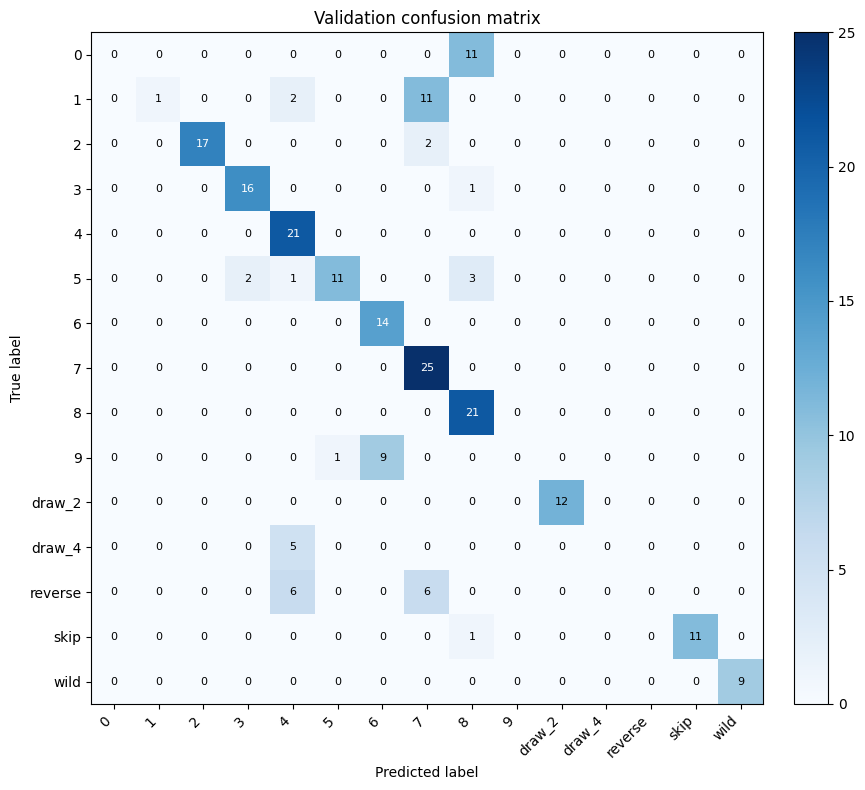

In [8]:
labels = [idx_to_class[idx] for idx in range(len(idx_to_class))]
matrix_np = matrix.numpy()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(matrix_np, cmap="Blues")
ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=45, ha="right")
ax.set_yticks(np.arange(len(labels)), labels=labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Validation confusion matrix")

threshold = matrix_np.max() / 2 if matrix_np.max() else 0
for row in range(matrix_np.shape[0]):
    for col in range(matrix_np.shape[1]):
        value = matrix_np[row, col]
        color = "white" if value > threshold else "black"
        ax.text(col, row, str(value), ha="center", va="center", color=color, fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()